In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv


The Data is highly imbalanced with only 4% of patients with target(stroke)=1 and 95% with target(stroke)=0.

By using trivial predicator, we can achieve an accuracy of 94.6% which seems good performance at first, however this trivial predictor is completely useless as it has absolutely no discriminatory power.

I will be using SMOTE algorithm in this notebook to balance the data.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly import tools
from plotly.subplots import make_subplots
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTEENN

In [3]:
df = pd.read_csv('/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.shape

(5110, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [8]:
df.drop('id', 1, inplace=True)

In [9]:
fig = px.bar(x=df['stroke'].value_counts().index, y=df['stroke'].value_counts(), text=(df['stroke'].value_counts()/len(df['stroke'])*100), height=500, width=500)
fig.update_traces(textposition='outside', texttemplate='%{text:.4s}%', marker_color=['peachpuff','silver'])
fig.show()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



<AxesSubplot:ylabel='Density'>

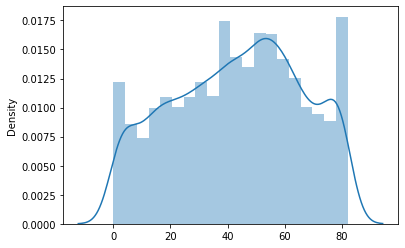

In [10]:
sns.distplot(x=df['age'])

In [11]:
fig = go.Figure()


fig.add_trace(go.Histogram(x=df['age'],
                          xbins=dict(
                          size=1),
                          opacity=1))

fig.update_layout(title_text='Age Distribution',
                 xaxis_title='Age',
                 yaxis_title='Count',
                 bargap=0.05,
                 xaxis={'showgrid':False},
                 yaxis={'showgrid':False},
                 template='ggplot2',
                 height=600,
                 width=1000)
fig.show()


In [12]:
trace1= go.Bar(x=df['gender'].value_counts().index, y=df['gender'].value_counts(), text = (df['gender'].value_counts()/len(df['gender'])*100), 
               marker_color=['lightpink','lightblue','grey'])

trace2= go.Bar(x=df['hypertension'].value_counts().index, y=df['hypertension'].value_counts(), text = (df['hypertension'].value_counts()/len(df['hypertension'])*100),
              marker_color=['plum','papayawhip'])

trace3= go.Bar(x=df['heart_disease'].value_counts().index, y=df['heart_disease'].value_counts(), text = (df['heart_disease'].value_counts()/len(df['heart_disease'])*100),
              marker_color=['mediumturquoise','lightgreen'])

trace4= go.Bar(x=df['ever_married'].value_counts().index, y=df['ever_married'].value_counts(), text = (df['ever_married'].value_counts()/len(df['ever_married'])*100),
              marker_color=['seagreen',"rgb(114, 78, 145)"])

trace5 = go.Bar(x=df['work_type'].value_counts().index, y=df['work_type'].value_counts(), text=(df['work_type'].value_counts()/len(df['work_type'])*100),
             marker_color=['rgb(56, 75, 126)', 'rgb(18, 36, 37)', 'rgb(34, 53, 101)','rgb(33, 75, 99)'])

trace6 = go.Bar(x=df['Residence_type'].value_counts().index, y=df['Residence_type'].value_counts(), text=(df['Residence_type'].value_counts()/len(df['Residence_type'])*100),
               marker_color=['palegreen','olive'])

fig = make_subplots(rows=3, cols=2, specs=[[{'type':'bar'},{'type':'bar'}],
                                          [{'type':'bar'},{'type':'bar'}],
                                          [{'type':'bar'},{'type':'bar'}]],
                   subplot_titles = ['Gender Distribution','Hypertension Distribution','Heart Disease Distribution','Married VS Single',
                   'Private OR Self-Employed','Resident Type Distribution'])

fig.append_trace(trace1,1,1)
fig.append_trace(trace2,1,2)
fig.append_trace(trace3,2,1)
fig.append_trace(trace4,2,2)
fig.append_trace(trace5,3,1)
fig.append_trace(trace6,3,2)

fig['layout'].update(height=1500, width=1000, title='Stroke Prediction Discrete Feature Analysis')
fig.update_traces(textposition='outside', texttemplate='%{text: .3s}%')
fig.show()

In [13]:
fig = go.Figure()


fig.add_trace(go.Histogram(x=df['avg_glucose_level'],
                          xbins=dict(
                          size=1),
                          opacity=1))

fig.update_layout(title_text='AVG_Glucose_Level',
                 xaxis_title='AVG_Glucose_Level',
                 yaxis_title='Count',
                 bargap=0.05,
                 xaxis={'showgrid':False},
                 yaxis={'showgrid':False},
                 template='seaborn',
                 height=600,
                 width=1000)
fig.show()


In [14]:

df['bmi'].fillna(df['bmi'].mean(), inplace=True)

In [15]:
fig = go.Figure()


fig.add_trace(go.Histogram(x=df['bmi'],
                          xbins=dict(
                          size=1),
                          opacity=1))

fig.update_layout(title_text='Body Mass Index',
                 xaxis_title='BMI',
                 yaxis_title='Count',
                 bargap=0.05,
                 xaxis={'showgrid':False},
                 yaxis={'showgrid':False},
                 template='plotly_white',
                 height=600,
                 width=1000)
fig.show()


In [16]:
numerical = df.select_dtypes(exclude=['object']).columns
numerical

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke'],
      dtype='object')

In [17]:
# Finding all the categorical columns from the data
categorical=df.select_dtypes(exclude=['int64','float64']).columns
categorical

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')

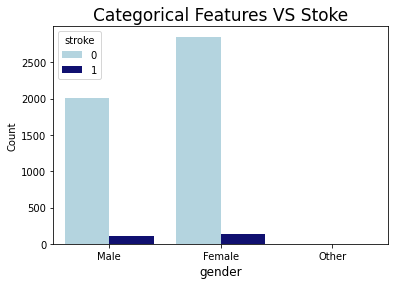

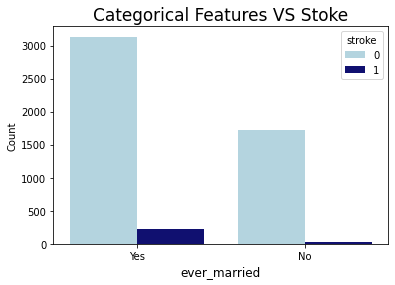

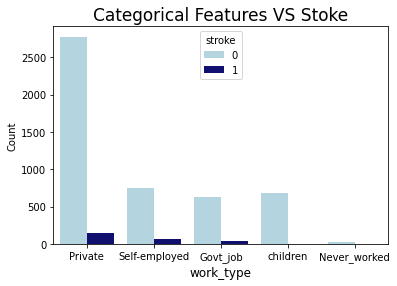

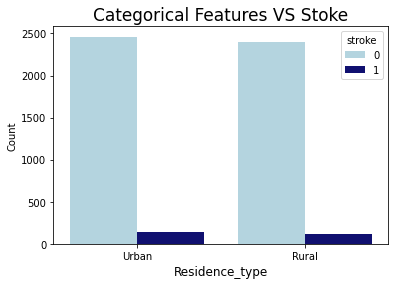

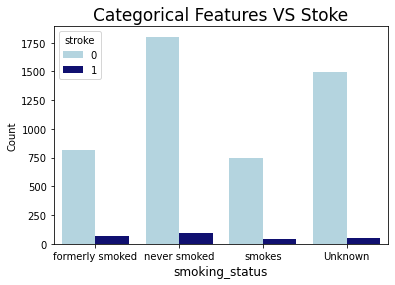

In [18]:
color=['lightblue','navy']
for i in categorical:
    sns.countplot(x=df[i], hue=df['stroke'], palette=color)
    plt.title('Categorical Features VS Stoke', fontsize=17)
    plt.xlabel(i, fontsize=12)
    plt.ylabel('Count')
    plt.show()

In [19]:
for i in numerical:
    fig = px.histogram(x=df[i], color=df['stroke'], height=500,width=800, title=str(i)+' VS Stroke', nbins=20)
    fig.show()

In [20]:
for i in categorical:
    df[i]=pd.factorize(df[i])[0]

In [21]:
df.head(3)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.600000,0,1
1,1,61.0,0,0,0,1,1,202.21,28.893237,1,1
2,0,80.0,0,1,0,0,1,105.92,32.500000,1,1


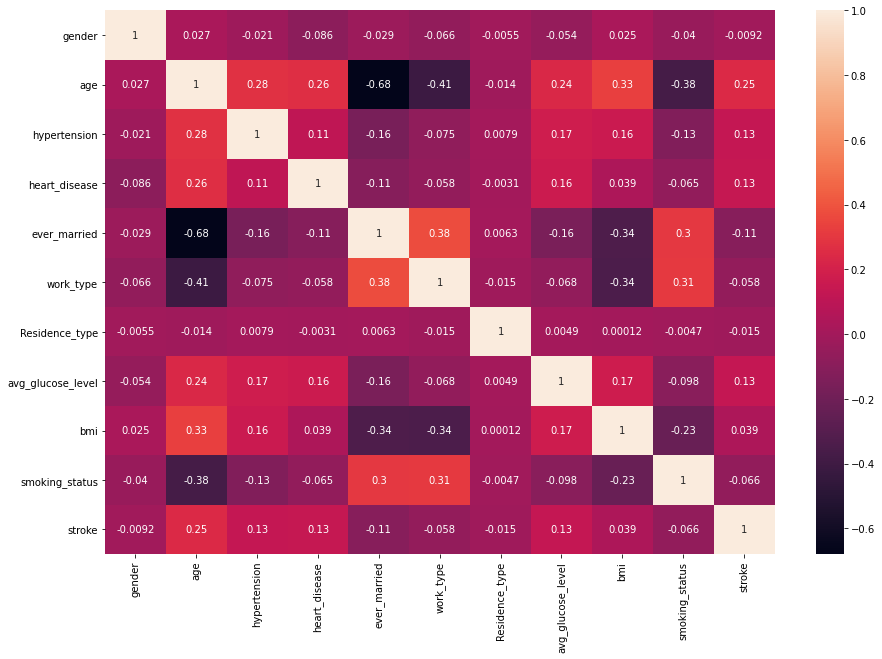

In [22]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [23]:
x = df.drop(['stroke'], axis=1).values
y = df['stroke'].values
print(x.shape)
print(y.shape)

(5110, 10)
(5110,)


# Random Forest Classifier

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=20, test_size=0.2, shuffle=True)

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import metrics

rf = RandomForestClassifier()

rf.fit(x_train, y_train)

RandomForestClassifier()

In [26]:
print('Accuracy score of Random Forest is: ', accuracy_score(y_test, rf.predict(x_test))*100,'%')

Accuracy score of Random Forest is:  94.52054794520548 %


<AxesSubplot:>

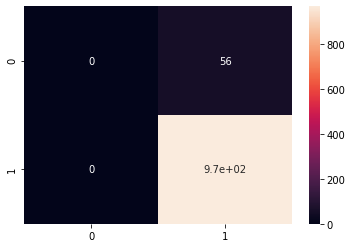

In [27]:
cf=metrics.confusion_matrix(y_test,rf.predict(x_test), labels=[1,0])
sns.heatmap(cf,annot=True)

In [28]:
# Now let's have a look at the report
print(metrics.classification_report(y_test,rf.predict(x_test), labels=[1,0]))
print('Accuracy_Score:',accuracy_score(y_test,rf.predict(x_test))*100,'%')
print('Recall:',metrics.recall_score(y_test,rf.predict(x_test))*100,'%')

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        56
           0       0.95      1.00      0.97       966

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.89      0.95      0.92      1022

Accuracy_Score: 94.52054794520548 %
Recall: 0.0 %


/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# XGBClassifier

In [29]:
from xgboost import XGBClassifier
xgb=XGBClassifier(use_label_encoder=False)

In [30]:
xgb.fit(x_train, y_train)
print('Accuracy of XGBClassifier is: ', accuracy_score(y_test, xgb.predict(x_test))*100,'%')

[14:20:46] WARNING: ../src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Accuracy of XGBClassifier is:  94.42270058708415 %


# Confusion Matrix

<AxesSubplot:>

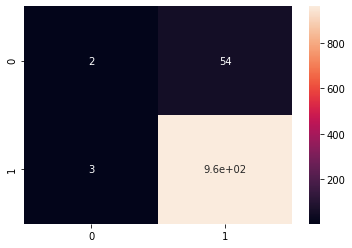

In [31]:
cf=metrics.confusion_matrix(y_test,xgb.predict(x_test), labels=[1,0])
sns.heatmap(cf,annot=True)

In [32]:
# Now let's have a look at the report
print(metrics.classification_report(y_test,xgb.predict(x_test), labels=[1,0]))
print('Accuracy_Score:',accuracy_score(y_test,xgb.predict(x_test))*100,'%')
print('Recall:',metrics.recall_score(y_test,xgb.predict(x_test))*100,'%')

              precision    recall  f1-score   support

           1       0.40      0.04      0.07        56
           0       0.95      1.00      0.97       966

    accuracy                           0.94      1022
   macro avg       0.67      0.52      0.52      1022
weighted avg       0.92      0.94      0.92      1022

Accuracy_Score: 94.42270058708415 %
Recall: 3.571428571428571 %


# LGBMCLASSIFIER

In [33]:
from lightgbm import LGBMClassifier
lgbm=LGBMClassifier()
lgbm.fit(x_train, y_train)

LGBMClassifier()

In [34]:
print('Accuracy of LGBMClassifier is: ', accuracy_score(y_test, lgbm.predict(x_test))*100,'%')

Accuracy of LGBMClassifier is:  94.52054794520548 %


<AxesSubplot:>

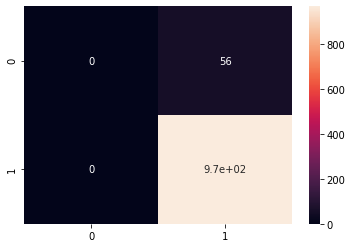

In [35]:
cf=metrics.confusion_matrix(y_test,rf.predict(x_test), labels=[1,0])
sns.heatmap(cf,annot=True)

In [36]:
# Now let's have a look at the report
print(metrics.classification_report(y_test,lgbm.predict(x_test), labels=[1,0]))
print('Accuracy_Score:',accuracy_score(y_test,lgbm.predict(x_test))*100,'%')
print('Recall:',metrics.recall_score(y_test,lgbm.predict(x_test))*100,'%')

              precision    recall  f1-score   support

           1       0.50      0.05      0.10        56
           0       0.95      1.00      0.97       966

    accuracy                           0.95      1022
   macro avg       0.72      0.53      0.53      1022
weighted avg       0.92      0.95      0.92      1022

Accuracy_Score: 94.52054794520548 %
Recall: 5.357142857142857 %


# SMOTE

SMOTE is an oversampling technique that generates synthetic samples from the minority class.

In [37]:
#before applying smote

one_count =0
zero_count = 1
for i in y:
    if i==1:
        one_count+=1
    else:
        zero_count+=1
print('The number of one are: ',one_count)
print('The number of zero are: ', zero_count)

The number of one are:  249
The number of zero are:  4862


In [38]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x,y,random_state=22, test_size=0.2, shuffle=True)

In [39]:
oversample = SMOTE(random_state=101)
x_train1, y_train1 = oversample.fit_resample(x_train1,y_train1)

In [40]:
#After applyig smote

one_count=0
zero_count =0
for i in y_train1:
    if i==1:
        one_count +=1
    else:
        zero_count +=1
print('The number of one are: ',one_count)
print('The number of zero are: ', zero_count)

The number of one are:  3894
The number of zero are:  3894


After applying the smote we can see that number of one and zeros are balanced now.

In [41]:
lgbm = LGBMClassifier()
lgbm.fit(x_train1, y_train1)

LGBMClassifier()

In [42]:
print('Accuracy of LGBMClassifier is: ', accuracy_score(y_test1, lgbm.predict(x_test1))*100,'%')

Accuracy of LGBMClassifier is:  94.22700587084148 %


# **Confusion Matrix**

<AxesSubplot:>

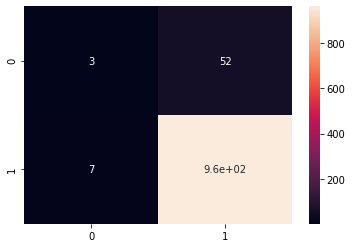

In [43]:
cf=metrics.confusion_matrix(y_test1,lgbm.predict(x_test1), labels=[1,0])
sns.heatmap(cf,annot=True)

In [44]:

print(metrics.classification_report(y_test1,lgbm.predict(x_test1), labels=[1,0]))
print('Accuracy_Score:',accuracy_score(y_test1,lgbm.predict(x_test1))*100,'%')
print('Recall:',metrics.recall_score(y_test1,lgbm.predict(x_test1))*100,'%')

              precision    recall  f1-score   support

           1       0.30      0.05      0.09        55
           0       0.95      0.99      0.97       967

    accuracy                           0.94      1022
   macro avg       0.62      0.52      0.53      1022
weighted avg       0.91      0.94      0.92      1022

Accuracy_Score: 94.22700587084148 %
Recall: 5.454545454545454 %


# SMOTEENN

SMOTEENN is used to downsample majority class.

In [45]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x,y,random_state=22, test_size=0.2, shuffle=True)

In [46]:
lgbm = LGBMClassifier()
lgbm.fit(x_train2, y_train2)

LGBMClassifier()

In [47]:
sme = SMOTEENN()
x_train2, y_train2 = sme.fit_resample(x_train2,y_train2)

In [48]:
lgbm.fit(x_train2,y_train2)

LGBMClassifier()

In [49]:
print('Accuracy of LGBMClassifier is: ', accuracy_score(y_test2, lgbm.predict(x_test2))*100,'%')

Accuracy of LGBMClassifier is:  90.1174168297456 %


<AxesSubplot:>

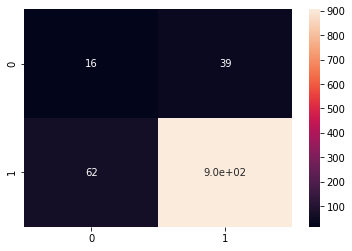

In [50]:
cf=metrics.confusion_matrix(y_test2,lgbm.predict(x_test2), labels=[1,0])
sns.heatmap(cf,annot=True)

In [51]:
# Now let's have a look at the report
print(metrics.classification_report(y_test2,lgbm.predict(x_test2), labels=[1,0]))
print('Accuracy_Score:',accuracy_score(y_test2,lgbm.predict(x_test2))*100,'%')
print('Recall:',metrics.recall_score(y_test2,lgbm.predict(x_test2))*100,'%')

              precision    recall  f1-score   support

           1       0.21      0.29      0.24        55
           0       0.96      0.94      0.95       967

    accuracy                           0.90      1022
   macro avg       0.58      0.61      0.59      1022
weighted avg       0.92      0.90      0.91      1022

Accuracy_Score: 90.1174168297456 %
Recall: 29.09090909090909 %


# Boderline SMOTE and RandomUnderSampling

Boderline SMOTE will not only oversample the miority data but majority data as well, where the majority data are causing misclassification in the decision boundary.

RandomUnderSampling randomly selecting examples from the majority class and deleting them from the training dataset.

In [52]:
x_train3, x_test3, y_train3, y_test3 = train_test_split( x, y, test_size=0.2, random_state=22, shuffle=True)

In [53]:
one_count=0
zero_count=0
for i in y_train3:
    if i==1:
        one_count+=1
    else:
        zero_count+=1
print('The number of 0 are:',zero_count)
print('The number of 1 are:',one_count)

The number of 0 are: 3894
The number of 1 are: 194


In [54]:
over = BorderlineSMOTE(sampling_strategy=0.3)
under = RandomUnderSampler(sampling_strategy=0.6)
steps = [('o', over), ('u', under)]

In [55]:
pipeline = Pipeline(steps=steps)
x_train3, y_train3 = pipeline.fit_resample(x_train3, y_train3)

In [56]:
# After
one_count=0
zero_count=0
for i in y_train3:
    if i==1:
        one_count+=1
    else:
        zero_count+=1
print('The number of 0 are:',zero_count)
print('The number of 1 are:',one_count)

The number of 0 are: 1946
The number of 1 are: 1168


In [57]:
lgbm = LGBMClassifier()
lgbm.fit(x_train3, y_train3)

LGBMClassifier()

In [58]:
print('Accuracy of LGBMClassifier is: ', accuracy_score(y_test3, lgbm.predict(x_test3))*100,'%')

Accuracy of LGBMClassifier is:  92.17221135029354 %


<AxesSubplot:>

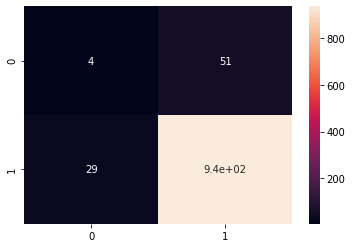

In [59]:
cf=metrics.confusion_matrix(y_test3,lgbm.predict(x_test3), labels=[1,0])
sns.heatmap(cf,annot=True)

In [60]:
print(metrics.classification_report(y_test3,lgbm.predict(x_test3), labels=[1,0]))
print('Accuracy_Score:',accuracy_score(y_test3,lgbm.predict(x_test3))*100,'%')
print('Recall:',metrics.recall_score(y_test3,lgbm.predict(x_test3))*100,'%')

              precision    recall  f1-score   support

           1       0.12      0.07      0.09        55
           0       0.95      0.97      0.96       967

    accuracy                           0.92      1022
   macro avg       0.53      0.52      0.53      1022
weighted avg       0.90      0.92      0.91      1022

Accuracy_Score: 92.17221135029354 %
Recall: 7.2727272727272725 %
